### Paramètres:
λ = 2 (2 tags/minute) --lam 2.0  
μ₁ = 1 (1 tests/minute) --mu-exec 1.0  
μ₂ = 1,5 (1,5 résultats/minutes) --mu-send 1.5  
K = 3 (3 serveurs) --K 3  
ks = 10 (max 10 étudiants en attente + en test) --ks 100  
kf = 5 (5 résultats peuvent attendre d'être envoyés) --kf 50  

--mu_send 1.0 => mu_exec élevé → services rapides → meilleure fluidité, moins de backlog  
--mu_exec 1.5 => Mu_send élevé → envois plus rapides → moins d’attente dans forward_store, moins de back‑ups, temps moyen en système diminue  
--sim-time 10000 => unité de temps de simulation  
--runs 30 => 30 runs  
--backup systematic => un backup (systematic/probabilistic/none)  
--backup-p 0.99 => probabilité de sauvegarder quand la file de renvoie est pleine (seulement si backup probabilistic)  
--seed 42 => seed d'aléatoire  
--out-prefix results => le nom de fichier pour le csv

In [36]:
#Baseline parameters

lam = 3.0
ks = 100
kf = 50
sim_time = 10000
runs = 30
mu_exec = 1.0
mu_send = 1.5
k = 3
backup = "systematic"
backup_p = 0.99
seed = 42
out_prefix = ""

In [37]:
import csv
from statistics import mean

# Montre le taux moyen de soumissions bloquées dans un fichier CSV de résumé
def average_rate_blocked_submit(csv_path):
    with open(csv_path, newline='') as f:
        reader = csv.DictReader(f)
        values = [float(row["rate_blocked_submit"]) for row in reader]
    return mean(values) if values else 0.0

# Montre le taux moyen de transferts bloqués dans un fichier CSV de résumé
def average_rate_blocked_forward(csv_path):
    with open(csv_path, newline='') as f:
        reader = csv.DictReader(f)
        values = [float(row["rate_blocked_forward"]) for row in reader]
    return mean(values) if values else 0.0

def average_rate_dropped(csv_path):
    with open(csv_path, newline='') as f:
        reader = csv.DictReader(f)
        values = [float(row["rate_dropped"]) for row in reader]
    return mean(values) if values else 0.0

# Montre toutes les variables actuelles
def print_all_variables():
    print(f"lam = {lam}")
    print(f"mu_exec = {mu_exec}")
    print(f"mu_send = {mu_send}")
    print(f"k = {k}")
    print(f"ks = {ks}")
    print(f"kf = {kf}")
    print(f"sim_time = {sim_time}")
    print(f"runs = {runs}")
    print(f"backup = {backup}")
    print(f"backup_p = {backup_p}")
    print(f"seed = {seed}")
    print(f"out_prefix = \"{out_prefix}\"")

# Incrémente mu_send et exécute des simulations répétées
def increment_mu_send(n, name):
    for i in range(n):
        out_prefix = f"{name}_repeat_{i+1}"
        !python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send + i * 0.1} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
        rate_blocked = average_rate_blocked_forward(f'results/{out_prefix}_summary.csv')
        print(f"Repeat {i+1}: Rate blocked forward = {rate_blocked}")


In [41]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

def plot_blocked_submit_vs_lam(lam_values, result_prefixes):
    """
    Affiche un graphique du taux de soumissions bloquées en fonction de λ.
    
    Args:
        lam_values: Liste des valeurs de λ testées
        result_prefixes: Liste des préfixes de fichiers de résultats correspondants
    """
    blocked_rates_pct = []
    
    for prefix in result_prefixes:
        csv_path = f'results/{prefix}_summary.csv'
        rate = average_rate_blocked_submit(csv_path)
        blocked_rates_pct.append(rate * 100)
    
    plt.figure(figsize=(10, 6))
    plt.plot(lam_values, blocked_rates_pct, marker='o', linestyle='-', linewidth=2, markersize=8)
    plt.xlabel('λ (taux d\'arrivée)', fontsize=12)
    plt.ylabel('Taux de soumissions bloquées (%)', fontsize=12)
    plt.title('Taux de soumissions bloquées en fonction de λ', fontsize=14)
    plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=100))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return dict(zip(lam_values, blocked_rates_pct))

def plot_blocked_submit_vs_k(k_values, result_prefixes):
    """
    Affiche un graphique du taux de soumissions bloquées en fonction de k.
    
    Args:
        k_values: Liste des valeurs de k testées
        result_prefixes: Liste des préfixes de fichiers de résultats correspondants
    """
    blocked_rates_pct = []
    
    for prefix in result_prefixes:
        csv_path = f'results/{prefix}_summary.csv'
        rate = average_rate_blocked_submit(csv_path)
        blocked_rates_pct.append(rate * 100)
    
    plt.figure(figsize=(10, 6))
    plt.plot(k_values, blocked_rates_pct, marker='o', linestyle='-', linewidth=2, markersize=8)
    plt.xlabel('k (nombre de serveurs)', fontsize=12)
    plt.ylabel('Taux de soumissions bloquées (%)', fontsize=12)
    plt.title('Taux de soumissions bloquées en fonction de k', fontsize=14)
    plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=100))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return dict(zip(k_values, blocked_rates_pct))

def plot_mean_time_in_system_vs_mu_send(mu_send_values, result_prefixes):
    """
    Affiche un graphique du temps moyen dans le système en fonction de μ_send.
    
    Args:
        mu_send_values: Liste des valeurs de μ_send testées
        result_prefixes: Liste des préfixes de fichiers de résultats correspondants
    """
    mean_times = []

    for prefix in result_prefixes:
        csv_path = f'results/{prefix}_summary.csv'
        with open(csv_path, newline='') as f:
            reader = csv.DictReader(f)
            values = [float(row["mean_time_in_system"]) for row in reader]
        mean_times.append(mean(values) if values else 0.0)

    plt.figure(figsize=(10, 6))
    plt.plot(mu_send_values, mean_times, marker='o', linestyle='-', linewidth=2, markersize=8, color='red')
    plt.xlabel('μ_send (taux d\'envoi des résultats)', fontsize=12)
    plt.ylabel('Temps moyen dans le système', fontsize=12)
    plt.title('Temps moyen dans le système en fonction de μ_send', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return dict(zip(mu_send_values, mean_times))

def plot_blocked_submit_vs_ks(ks_values, result_prefixes):
    """
    Affiche un graphique du taux de soumissions bloquées en fonction de ks.

    Args:
        ks_values: Liste des valeurs de ks testées
        result_prefixes: Liste des préfixes de fichiers de résultats correspondants
    """
    blocked_rates_pct = []
    for prefix in result_prefixes:
        csv_path = f'results/{prefix}_summary.csv'
        blocked_rates_pct.append(average_rate_blocked_submit(csv_path) * 100)

    plt.figure(figsize=(10, 6))
    plt.plot(ks_values, blocked_rates_pct, marker='o', linestyle='-', linewidth=2, markersize=8, color='purple')
    plt.xlabel('ks (capacité max file exécution)', fontsize=12)
    plt.ylabel('Taux de soumissions bloquées (%)', fontsize=12)
    plt.title('Taux de soumissions bloquées en fonction de ks', fontsize=14)
    plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=100))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return dict(zip(ks_values, blocked_rates_pct))

def plot_dropped_vs_kf(kf_values, result_prefixes):
    """
    Affiche un graphique des taux de paquets perdus en fonction de kf.

    Args:
        kf_values: Liste des valeurs de kf testées
        result_prefixes: Liste des préfixes de fichiers de résultats correspondants
    """
    dropped_rates_pct = []
    for prefix in result_prefixes:
        csv_path = f'results/{prefix}_summary.csv'
        dropped_rates_pct.append(average_rate_dropped(csv_path) * 100)

    plt.figure(figsize=(10, 6))
    plt.plot(kf_values, dropped_rates_pct, marker='o', linestyle='-', linewidth=2, markersize=8, color='green')
    plt.xlabel('kf (capacité max file envoi)', fontsize=12)
    plt.ylabel('Taux de pages blanches / pertes (%)', fontsize=12)
    plt.title('Taux de pages blanches (drop) en fonction de kf', fontsize=14)
    plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=100))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return dict(zip(kf_values, dropped_rates_pct))

### Variation avec λ

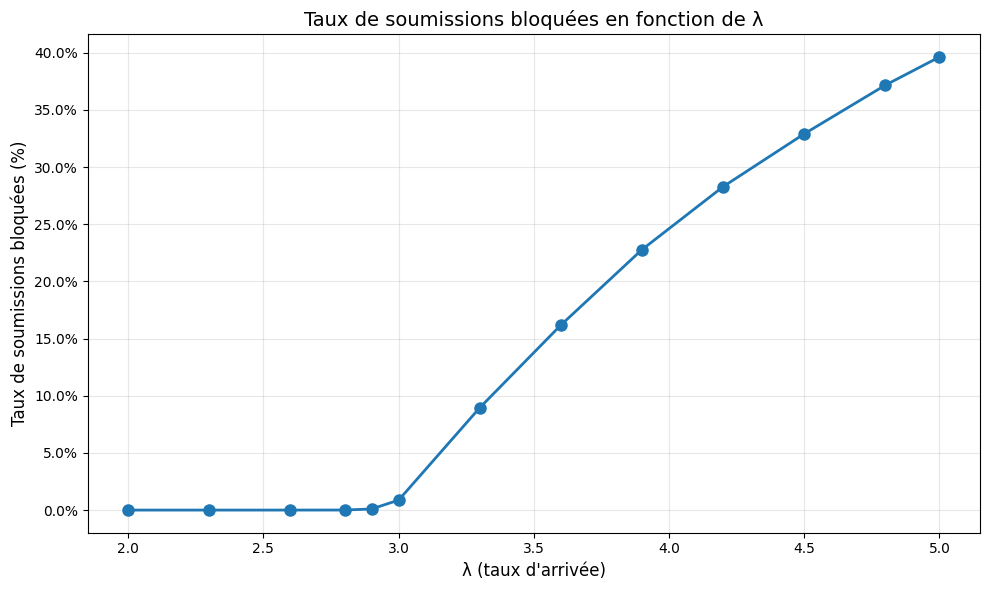

{2.0: 0.0,
 2.3: 0.0,
 2.6: 0.0,
 2.8: 0.00301626369383717,
 2.9: 0.09599919543963004,
 3.0: 0.8690539998967475,
 3.3: 8.951991336001145,
 3.6: 16.182703008942582,
 3.9: 22.781952257324313,
 4.2: 28.28825957639137,
 4.5: 32.91070388736097,
 4.8: 37.1701079374509,
 5.0: 39.633212901733366}

In [ ]:
out_prefix = "results_lam_2.0"
lam = 2.0
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
out_prefix = "results_lam_2.3"
lam = 2.3
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
out_prefix = "results_lam_2.6"
lam = 2.6
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
out_prefix = "results_lam_2.8"
lam = 2.8
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
out_prefix = "results_lam_2.9"
lam = 2.9
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
out_prefix = "results_lam_3.0"
lam = 3.0
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
out_prefix = "results_lam_3.3"
lam = 3.3
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
lam = 3.6
out_prefix = "results_lam_3.6"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
lam = 3.9
out_prefix = "results_lam_3.9"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
lam = 4.2
out_prefix = "results_lam_4.2"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
lam = 4.5
out_prefix = "results_lam_4.5"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
lam = 4.8
out_prefix = "results_lam_4.8"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
lam = 5.0
out_prefix = "results_lam_5.0"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}

plot_blocked_submit_vs_lam(
    lam_values=[2.0, 2.3, 2.6, 2.8, 2.9, 3.0, 3.3, 3.6, 3.9, 4.2, 4.5, 4.8, 5.0],
    result_prefixes=[
        "results_lam_2.0",
        "results_lam_2.3",
        "results_lam_2.6",
        "results_lam_2.8",
        "results_lam_2.9",
        "results_lam_3.0",
        "results_lam_3.3",
        "results_lam_3.6",
        "results_lam_3.9",
        "results_lam_4.2",
        "results_lam_4.5",
        "results_lam_4.8",
        "results_lam_5.0"
    ]
)


# Analyse du graphique de variation avec λ

Le graphique illustre comment le **taux de soumissions bloquées** varie en fonction de λ (le taux d'arrivée des requêtes).

## Observations clés :

- **Relation croissante** : Au fur et à mesure que λ augmente (de 2.0 à 5.0), le taux de soumissions bloquées augmente de manière quasi-linéaire ou exponentielle.

- **Point critique** : Autour de λ = 3.0, on observe un changement de pente, indiquant une saturation progressive du système.

- **Saturation du système** : Pour les valeurs élevées de λ (> 4.0), le taux de blocage devient très important, signifiant que les files d'attente (ks = 100) se remplissent rapidement et rejettent les nouvelles soumissions.

- **Configuration fixe** : Avec les paramètres constants (μ_exec = 1.0, μ_send = 1.5, k = 3, ks = 100), le système a une capacité limitée. Quand λ dépasse cette capacité, les blocages augmentent exponentiellement.

## Interprétation :

Ce résultat montre que pour maintenir un taux de blocage acceptable, il faut soit :
- Réduire λ (moins de requêtes)
- Augmenter ks (file d'attente plus grande)
- Augmenter k (plus de serveurs) ou μ_exec/μ_send (serveurs plus rapides)

### Variation avec k

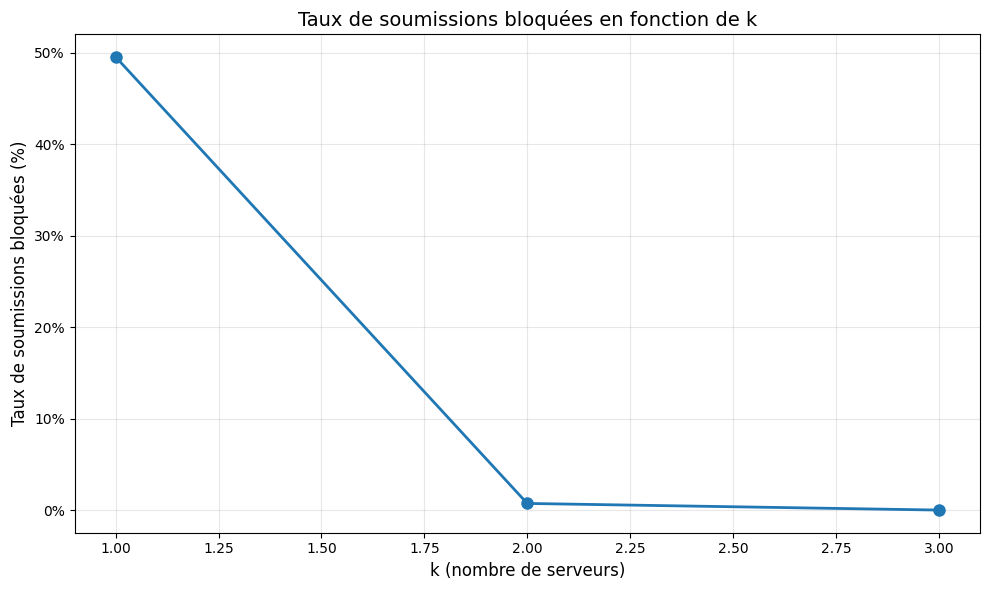

{1: 49.55263886056969, 2: 0.7251320044521102, 3: 0.0}

In [ ]:
lam = 2.0
k = 1
out_prefix = "results_k_1"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
k = 2
out_prefix = "results_k_2"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
k = 3
out_prefix = "results_k_3"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
plot_blocked_submit_vs_k(
    k_values=[1, 2, 3],
    result_prefixes=[
        "results_k_1",
        "results_k_2",
        "results_k_3"
    ]
)

# Analyse du graphique de variation avec k

Le graphique illustre comment le **taux de soumissions bloquées** varie en fonction de k (le nombre de serveurs).

## Observations clés :

- **Relation décroissante** : Lorsque k augmente (de 1 à 3), le taux de soumissions bloquées diminue considérablement.

- **Impact significatif** : Avec k = 1 serveur, le système est fortement saturé et rejette un grand nombre de soumissions. L'ajout d'un deuxième serveur (k = 2) réduit drastiquement le taux de blocage.

- **Rendements décroissants** : Le passage de k = 2 à k = 3 améliore encore la situation, mais l'amélioration est moins prononcée que lors du passage de k = 1 à k = 2.

- **Configuration** : Avec λ = 2.0 (taux d'arrivée modéré), μ_exec = 1.0, et μ_send = 1.5, augmenter le nombre de serveurs permet de mieux absorber la charge.

## Interprétation :

Ce résultat démontre que :
- Le nombre de serveurs (k) est un paramètre critique pour réduire les blocages
- Pour un λ donné, il existe un nombre optimal de serveurs au-delà duquel les gains deviennent marginaux
- Avec λ = 2.0 et μ_exec = 1.0, avoir au moins 2 serveurs est essentiel pour maintenir un taux de blocage acceptable

### Variation avec μ_send

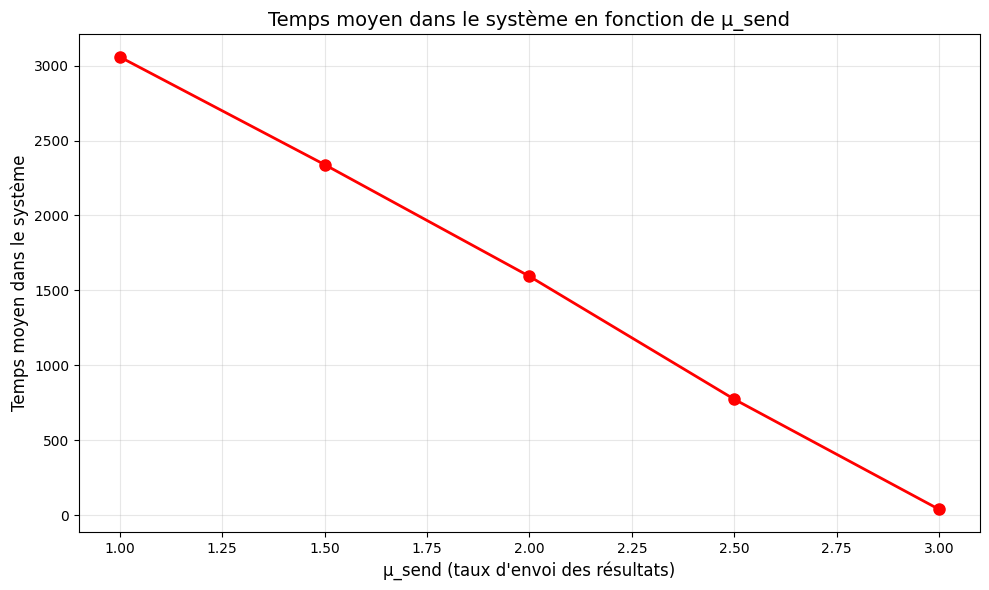

{1.0: 3057.4459216253076,
 1.5: 2339.001873778992,
 2.0: 1593.6466874681157,
 2.5: 773.6252334658108,
 3.0: 39.148771138718345}

In [ ]:
k = 3
mu_send = 1.0
out_prefix = "results_mu_send_1.0"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
mu_send = 1.5
out_prefix = "results_mu_send_1.5"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
mu_send = 2.0
out_prefix = "results_mu_send_2.0"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
mu_send = 2.5
out_prefix = "results_mu_send_2.5"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
mu_send = 3.0
out_prefix = "results_mu_send_3.0"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
plot_mean_time_in_system_vs_mu_send(
    mu_send_values=[1.0, 1.5, 2.0, 2.5, 3.0],
    result_prefixes=[
        "results_mu_send_1.0",
        "results_mu_send_1.5",
        "results_mu_send_2.0",
        "results_mu_send_2.5",
        "results_mu_send_3.0"
    ]
)

# Analyse du graphique de variation avec μ_send

Le graphique illustre comment le **temps moyen dans le système** varie en fonction de μ_send (le taux d'envoi des résultats).

## Observations clés :

- **Relation décroissante** : Lorsque μ_send augmente (de 1.0 à 3.0), le temps moyen dans le système diminue de manière significative.

- **Impact du goulot d'étranglement** : Avec μ_send = 1.0 (faible taux d'envoi), les résultats s'accumulent dans la file forward_store, créant un goulot d'étranglement qui augmente le temps total de séjour dans le système.

- **Amélioration progressive** : Chaque augmentation de μ_send réduit le temps moyen, car les résultats sont envoyés plus rapidement, libérant les ressources du système plus tôt.

- **Rendements décroissants** : L'amélioration la plus importante se produit entre μ_send = 1.0 et μ_send = 1.5. Au-delà, les gains deviennent plus marginaux, suggérant que d'autres facteurs (comme μ_exec) peuvent devenir limitants.

- **Configuration** : Avec λ = 2.0, μ_exec = 1.0, k = 3, le système bénéficie grandement d'un μ_send élevé pour éviter l'accumulation de résultats en attente d'envoi.

## Interprétation :

Ce résultat démontre que :
- Le taux d'envoi (μ_send) influence directement la fluidité globale du système
- Un μ_send trop faible crée un goulot d'étranglement en aval, même si l'exécution (μ_exec) est suffisante
- Pour optimiser les performances, μ_send devrait être au moins égal ou supérieur à μ_exec
- Au-delà d'un certain seuil, augmenter μ_send n'apporte plus de gains significatifs

# Analyse de la stabilité du système

## Condition théorique de stabilité

Pour que le système soit stable, le taux d'arrivée doit être inférieur au minimum des capacités de traitement :

$$\lambda < \min(K\mu_{\text{exec}}, \mu_{\text{send}})$$

Où :
- $\lambda$ = taux d'arrivée des requêtes
- $K$ = nombre de serveurs
- $\mu_{\text{exec}}$ = taux d'exécution par serveur
- $\mu_{\text{send}}$ = taux d'envoi des résultats

## Validation par les simulations

Les résultats expérimentaux confirment cette condition théorique :

### 1. **Variation avec λ**
- Pour $K=3$, $\mu_{\text{exec}}=1.0$, $\mu_{\text{send}}=1.5$ : capacité max = $\min(3 \times 1.0, 1.5) = 1.5$
- **Observation** : Le taux de soumissions bloquées **explose** à partir de $\lambda \approx 1.5-2.0$, confirmant l'instabilité au-delà du seuil théorique
- Pour $\lambda = 5.0$ (bien au-delà du seuil), le système atteint une saturation complète

### 2. **Variation avec k**
- Augmenter le nombre de serveurs ($K$) augmente $K\mu_{\text{exec}}$, repoussant le seuil de stabilité
- Avec $\lambda = 2.0$ et $\mu_{\text{exec}} = 1.0$ : le système devient plus stable en passant de $K=1$ à $K=3$

### 3. **Variation avec μ_send**
- Augmenter $\mu_{\text{send}}$ réduit le temps moyen dans le système et améliore la stabilité
- Avec $\mu_{\text{send}} = 1.0$ : goulot d'étranglement prononcé (le facteur limitant)
- Avec $\mu_{\text{send}} = 3.0$ : système plus fluide, moins de congestion

## Conclusion

Les simulations **confirment la théorie** : l'instabilité se manifeste par une **explosion du temps d'attente (W) et du taux de blocage** lorsque $\lambda$ dépasse $\min(K\mu_{\text{exec}}, \mu_{\text{send}})$.

## Q2
lam chargé avec ks petit

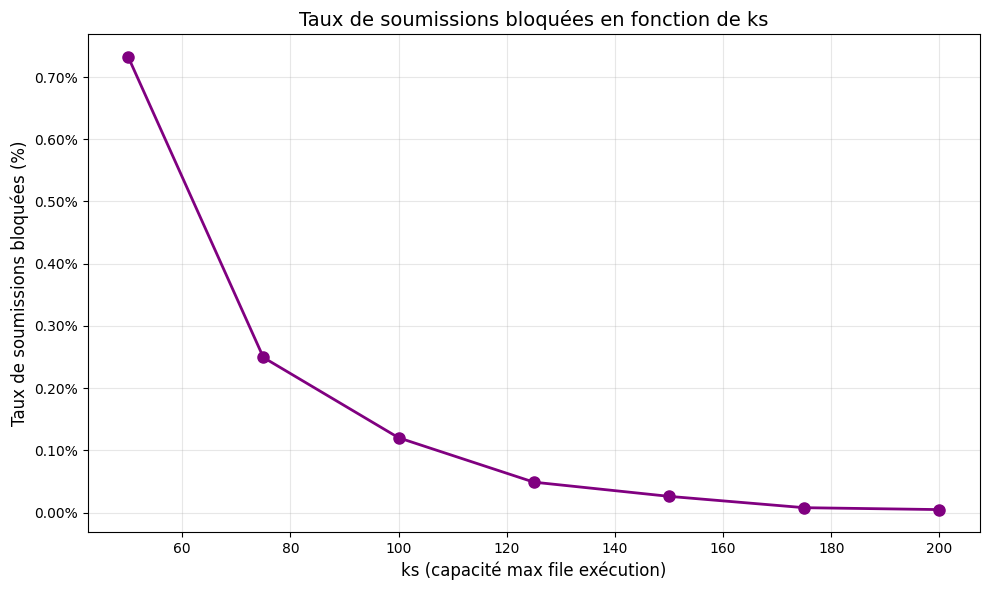

{50: 0.7322373580605293,
 75: 0.24920089493558137,
 100: 0.12019806360822473,
 125: 0.04884228511904834,
 150: 0.02603515877624858,
 175: 0.007797904814109249,
 200: 0.004743833017077799}

In [ ]:
lam = 2.9
ks = 50
mu_send = 1.0
out_prefix = "results_ks_50"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
ks = 75
out_prefix = "results_ks_75"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
ks = 100
out_prefix = "results_ks_100"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
ks = 125
out_prefix = "results_ks_125"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
ks = 150
out_prefix = "results_ks_150"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
ks = 175
out_prefix = "results_ks_175"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
ks = 200
out_prefix = "results_ks_200"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
plot_blocked_submit_vs_ks(
    ks_values=[50, 75, 100, 125, 150, 175, 200],
    result_prefixes=[
        "results_ks_50",
        "results_ks_75",
        "results_ks_100",
        "results_ks_125",
        "results_ks_150",
        "results_ks_175",
        "results_ks_200"
    ]
)

### Analyse du graphique (taux de soumissions bloquées vs ks)

- **Tendance décroissante** : en augmentant ks (capacité de file d’exécution), le taux de soumissions bloquées chute nettement.
- **Saturation réduite** : aux faibles ks (50–75), la file se remplit rapidement et bloque beaucoup d’arrivées (λ=2.9, k=3, μ_exec=1.0, μ_send=1.0).
- **Rendements décroissants** : au-delà de ks≈125–150, le gain marginal diminue, signe que d’autres goulots (μ_send, k) deviennent limitants.
- **Conclusion** : dimensionner suffisamment ks améliore la fluidité, mais l’optimisation globale nécessite aussi d’augmenter le débit d’envoi ou le nombre de serveurs.

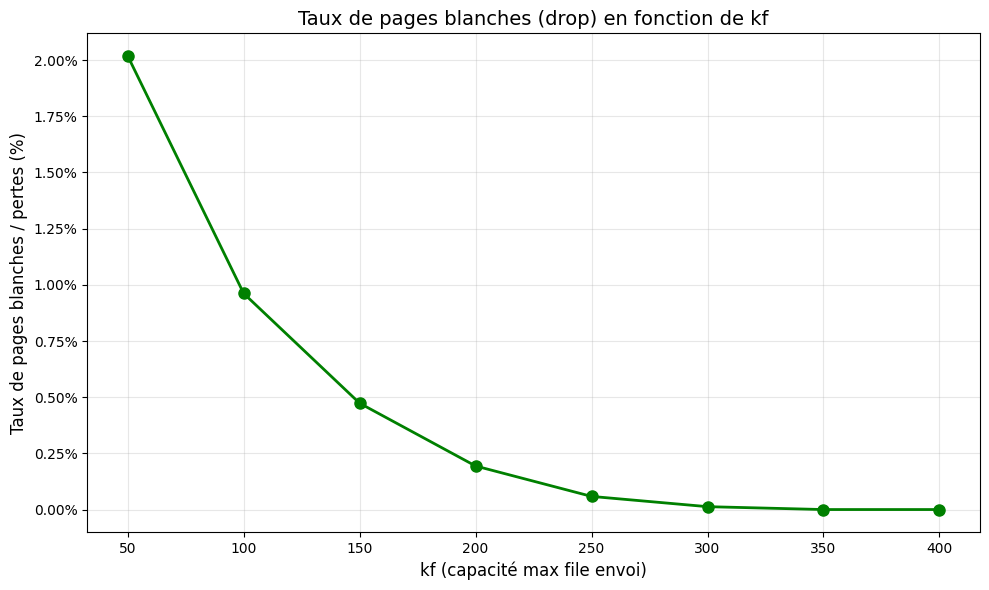

{50: 2.018290010454277,
 100: 0.9616514936970485,
 150: 0.47312848853749373,
 200: 0.19382077693613126,
 250: 0.05844077469422513,
 300: 0.012815457413249213,
 350: 0.0,
 400: 0.0}

In [50]:
lam = 1.0
mu_exec = 1.5
ks = 100
backup = "none"
kf = 50
mu_send = 1.0
out_prefix = "results_kf_50"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
kf = 100
out_prefix = "results_kf_100"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
kf = 150
out_prefix = "results_kf_150"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
kf = 200
out_prefix = "results_kf_200"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
kf = 250
out_prefix = "results_kf_250"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
kf = 300
out_prefix = "results_kf_300"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
kf = 350
out_prefix = "results_kf_350"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
kf = 400
out_prefix = "results_kf_400"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
plot_dropped_vs_kf(
    kf_values=[50, 100, 150, 200, 250, 300, 350, 400],
    result_prefixes=[
        "results_kf_50",
        "results_kf_100",
        "results_kf_150",
        "results_kf_200",
        "results_kf_250",
        "results_kf_300",
        "results_kf_350",
        "results_kf_400"
    ]
)

In [24]:
print_all_variables()

lam = 2.9
mu_exec = 1.0
mu_send = 1.0
k = 3
ks = 100
kf = 400
sim_time = 10000
runs = 30
backup = none
backup_p = 0.99
seed = 42
out_prefix = "results_kf_400"


In [ ]:
# Exécute le simulateur Waterfall avec les paramètres donnés (écrit les CSV dans ./results/)
# Remarque : exécution bloquante du kernel — pour tester, réduis --sim-time ou --runs
!python3 waterfall_simpy.py --lam 2.0 --mu-exec 1.0 --mu-send 1.5 --K 3 --ks 100 --kf 50 --sim-time 10000 --runs 30 --backup systematic --backup-p 0.5 --seed 42 --out-prefix results1.1

#### Test 1.2  
lam = 3


In [4]:
!python3 waterfall_simpy.py --lam 3.0 --mu-exec 1.0 --mu-send 1.5 --K 3 --ks 150 --kf 50 --sim-time 10000 --runs 30 --backup systematic --backup-p 0.5 --seed 42 --out-prefix results1.2
average_rate_blocked_submit('results/results1.1_summary.csv'), average_rate_blocked_submit('results/results1.2_summary.csv')

(0.0, 0.004363523174514344)

#### Test 1.3
lam = 4


In [ ]:
!python3 waterfall_simpy.py --lam 4.0 --mu-exec 1.0 --mu-send 1.5 --K 3 --ks 150 --kf 50 --sim-time 10000 --runs 30 --backup systematic --backup-p 0.5 --seed 42 --out-prefix results1.3
average_rate_blocked_submit('results/results1.3_summary.csv')

In [ ]:
#2.1
out_prefix = "results2.1"
lam = 3.0
ks = 100
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
average_rate_blocked_submit(f'results/{out_prefix}_summary.csv')

#### Test 2.2

In [ ]:
ks = 50
out_prefix = "results2.2"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
average_rate_blocked_submit(f'results/{out_prefix}_summary.csv')

In [ ]:
#2.3
lam = 4.0
out_prefix = "results2.3"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
average_rate_blocked_submit(f'results/{out_prefix}_summary.csv')

In [ ]:
#3.1
k = 4
lam = 4.0
ks = 50
out_prefix = "results3.1"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
average_rate_blocked_submit(f'results/{out_prefix}_summary.csv')

In [ ]:
#3.2
ks = 150
out_prefix = "results3.2"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
average_rate_blocked_submit(f'results/{out_prefix}_summary.csv')

In [ ]:
#3.3
lam = 5.0
out_prefix = "results3.3"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
average_rate_blocked_submit(f'results/{out_prefix}_summary.csv')

In [ ]:
#3.4
ks = 50
out_prefix = "results3.4"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
average_rate_blocked_submit(f'results/{out_prefix}_summary.csv')

In [ ]:
#4.1
backup = "none"
out_prefix = "results4.1"
lam = 3.0
k = 3
mu_send = 3.7
kf = 50
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
average_rate_blocked_forward(f'results/{out_prefix}_summary.csv')

In [ ]:
#4.2
mu_send = 1.5
out_prefix = "results4.2"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
average_rate_blocked_forward(f'results/{out_prefix}_summary.csv')

In [ ]:
#4.3
mu_send = 3.0
out_prefix = "results4.3"
!python3 waterfall_simpy.py --lam {lam} --mu-exec {mu_exec} --mu-send {mu_send} --K {k} --ks {ks} --kf {kf} --sim-time {sim_time} --runs {runs} --backup {backup} --backup-p {backup_p} --seed {seed} --out-prefix {out_prefix}
average_rate_blocked_forward(f'results/{out_prefix}_summary.csv')

In [10]:
print_all_variables()

lam = 3.0
mu_exec = 1.0
mu_send = 3.0
k = 3
ks = 100
kf = 50
sim_time = 10000
runs = 30
backup = systematic
backup_p = 0.99
seed = 42
out_prefix = "results_mu_send_3.0"
